# What If Simulator
## Player Market Value Engine

In [11]:
import pandas as pd
import numpy as np
import sqlite3
import time
import random
import re
import json
import sys
import asyncio
import os
import unicodedata
import threading
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from rapidfuzz import process, fuzz

import shap
from playwright.sync_api import sync_playwright
import nest_asyncio

if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
nest_asyncio.apply()


C:\Users\ashwy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Library usage**

* **`playwright` & `nest_asyncio`**: `playwright` simulates a real browser to bypass Transfermarkt's anti-scraping blocks, while `nest_asyncio` prevents it from crashing Jupyter's event loop.
* **`rapidfuzz`**: Calculates string similarity (fuzzy matching) to accurately merge player profiles across our two datasets when their names don't match exactly.
* **`sqlite3`**: Stores our merged dataset in a fast, lightweight relational database to enable instant querying for the simulator UI.
* **`time` & `random`**: Injects randomized, human-like delays between our scraping requests to prevent rate limits and IP bans.
* **`re` (Regular Expressions)**: Cleans text data—like converting `"€120.00m"` into `120000000` so our XGBoost model receives clean numerical inputs.
* **`json`**: Quickly parses structured player data that modern websites frequently embed inside hidden `<script>` tags.

In [ ]:
harvested_urls = []

def harvest_sofifa_urls_sync(target_count=7000):
    global harvested_urls
    player_urls = set()
    offset = 0
    base_url = "https://sofifa.com/players?offset="
    
    with sync_playwright() as p:
        browser = p.chromium.launch(headless=False) 
        page = browser.new_page()
        
        print(f"Initializing harvester for {target_count} players...")
        
        while len(player_urls) < target_count:
            current_url = f"{base_url}{offset}"
            
            try:
                # FIX: We changed 'networkidle' to 'domcontentloaded'. 
                # This stops waiting for ads/trackers and just looks at the HTML.
                page.goto(current_url, wait_until="domcontentloaded")
                
                # Wait directly for the player link to exist in the DOM
                page.wait_for_selector("a[href^='/player/']", timeout=15000)
                
                # Extract the profile links
                elements = page.query_selector_all("a[href^='/player/']")
                
                for el in elements:
                    href = el.get_attribute("href")
                    # Ensure it's a specific player profile, not a generic directory link
                    if href and len(href.split('/')) > 2: 
                        full_url = f"https://sofifa.com{href}"
                        player_urls.add(full_url)
                
                percentage = (len(player_urls) / target_count) * 100
                print(f"\r[Live Progress] Harvested: {len(player_urls)} / {target_count} URLs ({percentage:.1f}%)", end="", flush=True)
                
                if len(player_urls) >= target_count:
                    break
                    
                time.sleep(random.uniform(2.1, 4.5))
                offset += 60
                
            except Exception as e:
                print(f"\n[ERROR] Scraper stopped. The page title is currently: '{page.title()}'")
                print(f"Error Details: {e}")
                break 
            
        browser.close()
        harvested_urls = list(player_urls)[:target_count]

print("Starting harvester thread...")
scraper_thread = threading.Thread(target=harvest_sofifa_urls_sync, args=(7000,))
scraper_thread.start()
scraper_thread.join()

print(f"\n\nHarvest Complete! Total URLs ready for extraction: {len(harvested_urls)}")

In [ ]:
# SoFIFA Profile Parser (Test Batch)

# Defining the test batch 
test_urls = harvested_urls[:5]
scraped_players = []

def parse_sofifa_profiles(urls):
    global scraped_players
    
    with sync_playwright() as p:
        # Launching the visible browser to monitor behavior
        browser = p.chromium.launch(headless=False)
        page = browser.new_page()
        
        total_urls = len(urls)
        print(f"Starting test extraction for {total_urls} players...\n")
        
        for index, url in enumerate(urls, 1):
            try:
                # Loading the individual player profile
                page.goto(url, wait_until="domcontentloaded")
                page.wait_for_selector("h1", timeout=10000) 
                
                # Extracting the core identity
                name = page.locator("h1").first.inner_text()
                
                # Locating the main article tag which holds the actual player stats
                article_locator = page.locator("article").first
                
                # Extracting the entire text block of the player card
                raw_card_text = article_locator.inner_text() if article_locator.count() > 0 else "N/A"
                
                # Storing the raw data and replacing newlines with pipes for cleaner viewing
                player_data = {
                    "URL": url,
                    "Name": name,
                    "Raw_Card_Text": raw_card_text.replace('\n', ' | ')
                }
                
                scraped_players.append(player_data)
                
                # Updating the live progress tracker
                percentage = (index / total_urls) * 100
                progress_text = f"[Live Progress] Parsing: {index} / {total_urls} profiles ({percentage:.1f}%) | Last extracted: {name}"
                print(f"\r{progress_text.ljust(85)}", end="", flush=True)
                
            except Exception as e:
                print(f"\n[ERROR] Failing to extract data from {url}. Error: {e}")
            
            # Sleeping to mimic human behavior and avoid IP bans
            time.sleep(random.uniform(1.5, 3.5))
            
        browser.close()

# Running the parser thread
print("Starting parser thread...")
parser_thread = threading.Thread(target=parse_sofifa_profiles, args=(test_urls,))
parser_thread.start()
parser_thread.join()

# Displaying the clean DataFrame results
print("\n\n--- Test Batch Results ---")
df_test = pd.DataFrame(scraped_players)
print(df_test)

In [ ]:
# Full SoFIFA Profile Extraction (7,000 Players) 

os.makedirs("data",exist_ok=True)   

# Storing the full dataset
full_scraped_players = []

# Defining the backup file path
backup_filepath = "data/sofifa_raw_data_backup.csv"

def parse_all_sofifa_profiles(urls):
    global full_scraped_players
    
    with sync_playwright() as p:
        # Launching visibly to mimic human behavior and avoid bot detection
        browser = p.chromium.launch(headless=False)
        page = browser.new_page()
        
        total_urls = len(urls)
        print(f"Starting full extraction for {total_urls} players.")
        
        for index, url in enumerate(urls, 1):
            try:
                # Loading the individual player profile
                page.goto(url, wait_until="domcontentloaded")
                page.wait_for_selector("h1", timeout=10000) 
                
                # Extracting the core identity
                name = page.locator("h1").first.inner_text()
                
                # Locating the main article tag 
                article_locator = page.locator("article").first
                
                # Extracting the entire text block of the player card
                raw_card_text = article_locator.inner_text() if article_locator.count() > 0 else "N/A"
                
                # Storing the raw data
                player_data = {
                    "URL": url,
                    "Name": name,
                    "Raw_Card_Text": raw_card_text.replace('\n', ' | ')
                }
                
                full_scraped_players.append(player_data)
                
                # Saving a backup to your local drive every 50 players to prevent data loss
                if index % 50 == 0:
                    pd.DataFrame(full_scraped_players).to_csv(backup_filepath, index=False)
                
                # Updating the live progress tracker
                percentage = (index / total_urls) * 100
                progress_text = f"[Live Progress] Parsing: {index} / {total_urls} profiles ({percentage:.1f}%) | Last extracted: {name}"
                print(f"\r{progress_text.ljust(85)}", end="", flush=True)
                
            except Exception as e:
                # Logging errors cleanly without stopping the entire loop
                print(f"\n[ERROR] Failing to extract data from {url}. Error: {e}")
            
            # Sleeping to mimic human behavior and avoid IP bans
            time.sleep(random.uniform(1.5, 3.5))
            
        browser.close()
        
        # Saving the final, complete dataset
        pd.DataFrame(full_scraped_players).to_csv("data/sofifa_raw_data_COMPLETE.csv", index=False)

# Running the parser thread on the full list of harvested URLs
print("Starting parser thread for the full batch...")
parser_thread = threading.Thread(target=parse_all_sofifa_profiles, args=(harvested_urls,))
parser_thread.start()

# Letting the thread run in the background 
parser_thread.join()

print("\n\nExtraction Complete! Data is safely saved to 'data/sofifa_raw_data_COMPLETE.csv'.")

In [6]:
df = pd.read_csv("data/sofifa_raw_data_COMPLETE.csv")
print(df['Raw_Card_Text'].iloc[0])

  | Caleb James Roberts |  |  CM CAM CDM | 19y.o. (Oct 24, 2005) 178cm 5'10" 74kg 163lbs |  | 56 | Overall rating | 	70 | Potential | 	€350K | Value | 	€600 | Wage |  9  1 Follow (12)  | History version (122) |   | Add to shortlist |  Customize Calculator | Profile |  | Preferred foot Right |  | 2  Skill moves |  | 3  Weak foot |  | 1  International reputation |  | Body type Lean (170-185) |  | Real face No |  | Release clause €831K |  | Acceleration type Controlled |  | 	 | Player specialities | 	 | Club |  |  Plymouth Argyle |  |  League One |  | 66  |  | Position RES |  | Kit number 24 |  | Joined Oct 24, 2022 |  | Contract valid until 2028 |  | 	 | Roles |  | Box-to-Box + |  | CM |  | Balanced | Ball-winning |  | 			 | Layout 1 2 3 | Attacking |  | 38 Crossing |  | 38 Finishing |  | 44 Heading accuracy |  | 61 Short passing |  | 38 Volleys |  | 	 | Skill |  | 59 Dribbling |  | 45 Curve |  | 37 FK Accuracy |  | 58 Long passing |  | 59 Ball control |  | 	 | Movement |  | 65 Accelerat

In [ ]:
#Data Cleaning 
# Ensuring the data directory exists
os.makedirs("data", exist_ok=True)

# Load the raw dataset
df = pd.read_csv("data/sofifa_raw_data_COMPLETE.csv")

def extract_granular_stat(text, stat_name):
    pattern = r'\|\s*(\d{1,2})\s*' + re.escape(stat_name) + r'\s*\|'
    match = re.search(pattern, str(text), re.IGNORECASE)
    return int(match.group(1)) if match else None

def extract_core_rating(text, keyword):
    pattern = r'\|\s*(\d{1,2})\s*\|\s*' + re.escape(keyword) + r'\s*\|'
    match = re.search(pattern, str(text), re.IGNORECASE)
    return int(match.group(1)) if match else None

print("Parsing raw text blocks into precise behavioral features...")

# Extract 6 highly predictive granular stats instead of broad aggregates
df['Sprint_Speed'] = df['Raw_Card_Text'].apply(lambda x: extract_granular_stat(x, 'Sprint speed'))
df['Finishing'] = df['Raw_Card_Text'].apply(lambda x: extract_granular_stat(x, 'Finishing'))
df['Short_Passing'] = df['Raw_Card_Text'].apply(lambda x: extract_granular_stat(x, 'Short passing'))
df['Dribbling'] = df['Raw_Card_Text'].apply(lambda x: extract_granular_stat(x, 'Dribbling'))
df['Standing_Tackle'] = df['Raw_Card_Text'].apply(lambda x: extract_granular_stat(x, 'Standing tackle'))
df['Strength'] = df['Raw_Card_Text'].apply(lambda x: extract_granular_stat(x, 'Strength'))

# Extract Overall and Potential ratings
df['Overall'] = df['Raw_Card_Text'].apply(lambda x: extract_core_rating(x, 'Overall rating'))
df['Potential'] = df['Raw_Card_Text'].apply(lambda x: extract_core_rating(x, 'Potential'))

# Drop the messy raw column and any rows where the parser failed to find an Overall rating
df_clean = df.drop(columns=['Raw_Card_Text']).dropna(subset=['Overall', 'Sprint_Speed'])

# Save the final cleaned behavioral dataset
df_clean.to_csv("data/sofifa_cleaned_behavioral.csv", index=False)

print(f"Cleaning complete. Retained {len(df_clean)} players with fully structured behavioral profiles.")
display(df_clean.head())

Parsing raw text blocks into precise behavioral features...
Cleaning complete. Retained 6684 players with fully structured behavioral profiles.


,URL,Name,Sprint_Speed,Finishing,Short_Passing,Dribbling,Standing_Tackle,Strength,Overall,Potential
0,https://sofifa.com/player/272465/caleb-roberts...,Caleb Roberts,66.0,38.0,61.0,59.0,58.0,58.0,56.0,70.0
1,https://sofifa.com/player/random?1775801033,Javier Villar del Fraile,62.0,56.0,69.0,66.0,68.0,59.0,65.0,74.0
2,https://sofifa.com/player/274482/adrian-ascues...,Adrián Ascues,73.0,61.0,68.0,61.0,54.0,74.0,65.0,73.0
3,https://sofifa.com/player/272535/josh-bailey/2...,Josh Bailey,69.0,30.0,40.0,48.0,46.0,51.0,52.0,63.0
4,https://sofifa.com/player/271880/nestor-jimene...,Nestor Jiménez,59.0,67.0,60.0,66.0,20.0,52.0,61.0,70.0


In [ ]:
df_raw = pd.read_csv("data/sofifa_raw_data_COMPLETE.csv")
df_clean = pd.read_csv("data/sofifa_cleaned_behavioral.csv")

# Extract the 2-digit age right before the "y.o." pattern
df_raw['Age'] = df_raw['Raw_Card_Text'].str.extract(r'(\d{2})y\.o\.')

# Merge the Age column into the clean dataset using the 'URL' as the perfect key
df_clean = df_clean.merge(df_raw[['URL', 'Age']], on='URL', how='left')

# Drop any rows where Age failed to extract to keep the dataset pristine
df_clean = df_clean.dropna(subset=['Age'])
df_clean['Age'] = df_clean['Age'].astype(int)

# Save the updated clean dataset
df_clean.to_csv("data/sofifa_cleaned_behavioral.csv", index=False)

print("Age successfully rescued and integrated!")
display(df_clean[['Name', 'Age']].head())

Age successfully rescued and integrated!


,Name,Age
0,Caleb Roberts,19
1,Javier Villar del Fraile,22
2,Adrián Ascues,21
3,Josh Bailey,18
4,Nestor Jiménez,22


### Feature Selection Rationale: Why We Dropped 80% of the Granular Stats

To predict market value effectively using XGBoost, we aggressively pruned the 40+ raw attributes down to 6-8 core features. Here is the technical rationale for this dimensionality reduction:

* **Preventing Multicollinearity:** Features like `Acceleration` and `Sprint Speed` (or `Standing Tackle` and `Sliding Tackle`) are highly correlated. Feeding both into tree-based models causes feature importance splitting, which ruins the SHAP values we need for model interpretability later. We retained single, strong proxies for each physical/technical domain.
* **Mitigating Overfitting (Curse of Dimensionality):** With a relatively small dataset (n ≈ 7,000), retaining 40+ features encourages the model to memorize specific stat combinations rather than learning generalized economic rules.
* **Optimizing Signal-to-Noise Ratio:** Granular attributes (e.g., `14 GK Diving`, `38 Volleys`, `FK Accuracy`) introduce mathematical noise. Market value is overwhelmingly driven by core competencies and aggregate ratings, not niche metrics. 
* **Simulator UI Constraints:** The final deliverable requires an interactive "What-If" simulator. Requiring end-users to adjust 40 distinct sliders to observe a price change is poor UX. Condensing to core features ensures a responsive, intuitive deployment.

In [ ]:
# Transfermarkt Financial Data Extraction 
# Ensure the data directory exists
os.makedirs("data", exist_ok=True)

tm_scraped_players = []
backup_filepath = "data/transfermarkt_raw_backup.csv"

TOTAL_PAGES = 280 
BASE_URL = "https://www.transfermarkt.co.in/spieler-statistik/wertvollstespieler/marktwertetop?page="

def scrape_transfermarkt_lists():
    global tm_scraped_players
    
    with sync_playwright() as p:
        # Launching visibly is mandatory here to pass basic bot checks
        browser = p.chromium.launch(headless=False)
        context = browser.new_context(
            user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
        )
        page = context.new_page()
        
        for current_page in range(1, TOTAL_PAGES + 1):
            target_url = f"{BASE_URL}{current_page}"
            
            try:
                page.goto(target_url, wait_until="domcontentloaded")
                # Wait for the main data table to render
                page.wait_for_selector("table.items", timeout=15000)
                
                # Locate all player rows (ignoring headers)
                rows = page.locator("table.items tbody tr.odd, table.items tbody tr.even").all()
                
                for row in rows:
                    try:
                        # Extracting the raw text of the row and splitting it
                        # TM rows usually contain: [Rank, Player Image, Name, Position, Age, Nat, Club, Value]
                        row_text = row.inner_text().split('\n')
                        
                        # Filtering out empty strings
                        cleaned_row = [item.strip() for item in row_text if item.strip()]
                        
                        # Index 0 is rank, 1 is Name, 2 is Position, 3 is Age, Last is Value
                        name = cleaned_row[1] if len(cleaned_row) > 1 else "N/A"
                        position = cleaned_row[2] if len(cleaned_row) > 2 else "N/A"
                        age = cleaned_row[3] if len(cleaned_row) > 3 else "N/A"
                        market_value = cleaned_row[-1] if len(cleaned_row) > 0 else "N/A"
                        
                        tm_scraped_players.append({
                            "TM_Name": name,
                            "TM_Position": position,
                            "TM_Age": age,
                            "Market_Value": market_value
                        })
                    except Exception as row_err:
                        continue        # Silently skip malformed rows rather than crashing the whole page
                
                # Save backup every 10 pages
                if current_page % 10 == 0:
                    pd.DataFrame(tm_scraped_players).to_csv(backup_filepath, index=False)
                
                percentage = (current_page / TOTAL_PAGES) * 100
                print(f"\r[Live Progress] Scraping Page: {current_page} / {TOTAL_PAGES} ({percentage:.1f}%) | Players banked: {len(tm_scraped_players)}", end="", flush=True)
                
            except Exception as e:
                print(f"\n[ERROR] Failed on page {current_page}. Moving to next. Error: {e}")
            
            # MANDATORY BOT DELAY. DO NOT SHORTEN THIS.
            time.sleep(random.uniform(3.5, 6.5))
            
        browser.close()
        
        # Saving final dataset
        pd.DataFrame(tm_scraped_players).to_csv("data/transfermarkt_raw_COMPLETE.csv", index=False)

# Execute the scraper

print("Starting parser thread for the Transfermarkt batch...")
tm_thread = threading.Thread(target=scrape_transfermarkt_lists)
tm_thread.start()
tm_thread.join()
print("\n\nExtraction Complete! Data is safely saved to 'data/transfermarkt_raw_COMPLETE.csv'.")

Starting parser thread for the Transfermarkt batch...
[Live Progress] Scraping Page: 280 / 280 (100.0%) | Players banked: 7000

Extraction Complete! Data is safely saved to 'data/transfermarkt_raw_COMPLETE.csv'.


In [ ]:
# Load your scraped data
df_tm = pd.read_csv("data/transfermarkt_raw_COMPLETE.csv")

def clean_mashed_row(row):
    age_val = str(row['TM_Age'])
    # If the Age column contains the messy mashed string with the currency symbol
    if '₹' in age_val:
        # Extract the 2-digit age
        age_match = re.search(r'(\d{2})', age_val)
        if age_match:
            row['TM_Age'] = age_match.group(1)
        
        # Extract the currency string
        val_match = re.search(r'(₹[\d,\.]+\s*[A-Za-z]+)', age_val)
        if val_match:
            row['Market_Value'] = val_match.group(1)
            
    return row

print("Untangling mashed rows...")
# Apply the fix across the dataset
df_tm = df_tm.apply(clean_mashed_row, axis=1)

# Ensure Age is just numeric strings, dropping any weird leftover characters
df_tm['TM_Age'] = df_tm['TM_Age'].astype(str).str.extract(r'(\d{2})')[0]

# Display the fixed rows to verify (e.g., Lamine Yamal, Haaland, Pedri)
display(df_tm.head())

# Save it back to the file
df_tm.to_csv("data/transfermarkt_raw_COMPLETE.csv", index=False)
print("\nData cleaned and overwritten successfully.")

Untangling mashed rows...


,TM_Name,TM_Position,TM_Age,Market_Value
0,Lamine Yamal,Right Winger,18,"₹1,600 Cr"
1,Erling Haaland,Centre-Forward,25,"₹1,600 Cr"
2,Kylian Mbappé,Centre-Forward,27,"₹1,600 Cr"
3,Pedri,Central Midfield,23,"₹1,200 Cr"
4,Vinicius Junior,Left Winger,25,"₹1,200 Cr"



Data cleaned and overwritten successfully.


In [ ]:
#Phase 3 - Strict Entity Resolution 

df_sofifa = pd.read_csv("data/sofifa_cleaned_behavioral.csv")
df_tm = pd.read_csv("data/transfermarkt_raw_COMPLETE.csv")

def normalize_and_strip(text):
    if pd.isna(text): return ""
    text = str(text)
    text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    text = re.sub(r'[^\w\s]', '', text)
    return text.lower().strip()

df_sofifa['Normalized_Name'] = df_sofifa['Name'].apply(normalize_and_strip)
df_tm['Normalized_TM_Name'] = df_tm['TM_Name'].apply(normalize_and_strip)

def clean_currency_to_euro(val_str):
    if pd.isna(val_str) or val_str == "N/A": return 0
    clean_str = str(val_str).replace('₹', '').replace(',', '').strip()
    multiplier = 1
    if 'cr' in clean_str.lower():
        multiplier = 10_000_000
        clean_str = re.sub(r'(?i)cr', '', clean_str).strip()
    if 'k' in clean_str.lower():
        multiplier *= 1_000
        clean_str = re.sub(r'(?i)k', '', clean_str).strip()
    if 'm' in clean_str.lower():
        multiplier *= 1_000_000
        clean_str = re.sub(r'(?i)m', '', clean_str).strip()
    try:
        return int((float(clean_str) * multiplier) / 108.66)    #exchange rate as of 11-04-2026
    except:
        return 0

df_tm['Value_EUR'] = df_tm['Market_Value'].apply(clean_currency_to_euro)
df_tm = df_tm[df_tm['Value_EUR'] > 0].copy()
df_tm['TM_Age'] = pd.to_numeric(df_tm['TM_Age'], errors='coerce')


In [ ]:
tm_records = df_tm.to_dict('records')
unified_data = []
matched_count = 0

for index, sf_row in df_sofifa.iterrows():
    sf_name_norm = sf_row['Normalized_Name']
    sf_age = sf_row['Age']
    best_match_score = 0
    best_match_record = None
    
    for tm_row in tm_records:
        tm_name_norm = tm_row['Normalized_TM_Name']
        tm_age = tm_row['TM_Age']
        
        # Exact Match
        if sf_name_norm == tm_name_norm:
            best_match_record = tm_row
            break
            
        # STRICT MATCHING: token_set_ratio >= 85 (No more false positives)
        score = fuzz.token_set_ratio(sf_name_norm, tm_name_norm)
        if score >= 85 and pd.notna(sf_age) and pd.notna(tm_age):
            if abs(sf_age - tm_age) <= 1:
                if score > best_match_score:
                    best_match_score = score
                    best_match_record = tm_row

    if best_match_record:
        merged_row = {**sf_row, 'Target_Value_EUR': best_match_record['Value_EUR']}
        merged_row.pop('Normalized_Name', None)
        unified_data.append(merged_row)
        matched_count += 1

df_unified = pd.DataFrame(unified_data)
df_unified.to_csv("data/UNIFIED_ML_DATASET.csv", index=False)

print(f"\nStrict Phase 3 Complete! Successfully merged {matched_count} verified players.")


Strict Phase 3 Complete! Successfully merged 332 verified players.


## EDA

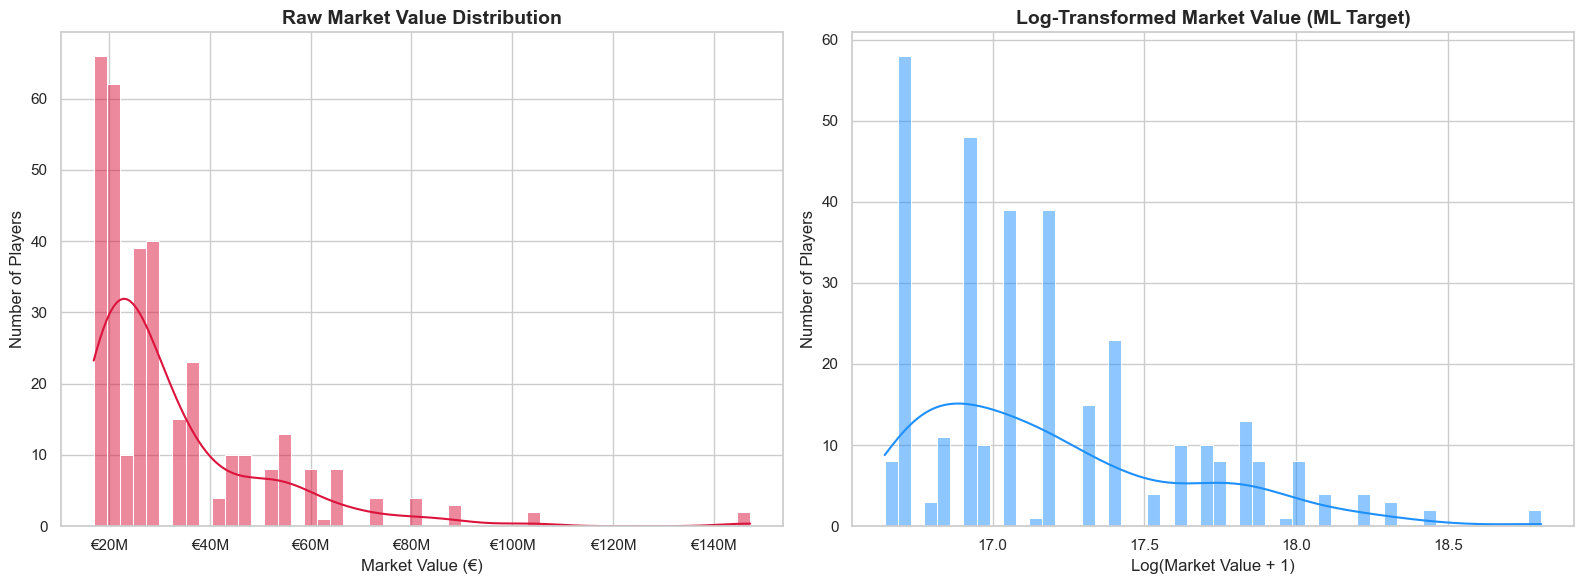


Level 1 Complete: 'Log_Target_Value_EUR' successfully engineered and saved.


In [7]:
# EDA Level 1 -  Target Variable Autopsy 

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/UNIFIED_ML_DATASET.csv")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1
sns.histplot(df['Target_Value_EUR'], bins=50, kde=True, ax=axes[0], color='crimson')
axes[0].set_title("Raw Market Value Distribution", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Market Value (€)")
axes[0].set_ylabel("Number of Players")

# Format the x-axis to show millions (M) clearly so it isn't just scientific notation
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'€{x*1e-6:.0f}M'))

#  The Mathematical Fix 
# We use log1p (log(1+x)) to handle any zeros safely, compressing the massive outliers
df['Log_Target_Value_EUR'] = np.log1p(df['Target_Value_EUR'])

# Plot 2:(Log-Transformed) 
sns.histplot(df['Log_Target_Value_EUR'], bins=50, kde=True, ax=axes[1], color='dodgerblue')
axes[1].set_title("Log-Transformed Market Value (ML Target)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Log(Market Value + 1)")
axes[1].set_ylabel("Number of Players")

plt.tight_layout()
plt.show()

# Overwrite the dataset to permanently include the new log-transformed column
df.to_csv("data/UNIFIED_ML_DATASET.csv", index=False)
print("\nLevel 1 Complete: 'Log_Target_Value_EUR' successfully engineered and saved.")

### EDA Phase 1: Target Variable Transformation (Target_Value_EUR)
#### Observation:
An initial analysis of the raw target variable (Target_Value_EUR) revealed severe right-skewness. The player valuations are heavily concentrated in the lower percentiles (under €40M), with a sparse, extended tail of elite outliers stretching past €140M.

#### Engineering Decision:
A logarithmic transformation (np.log1p) was applied to the target variable to create the final modeling target: Log_Target_Value_EUR.

#### Data Science Rationale:
- **Loss Function Stabilization**: If fed raw data, a regression model optimizing for Mean Squared Error (MSE) would disproportionately penalize itself for errors on ultra-high-value players (e.g., Kylian Mbappé), effectively ignoring the underlying mechanics of average-valued players. The log transformation compresses this magnitude variance, forcing the XGBoost algorithm to optimize for relative (percentage) error rather than absolute error.
- **Discrete Market Bucketing**: The resulting log-distribution exhibits distinct, discrete binning (visible as vertical spikes). This accurately maps to real-world domain logic, as the global transfer market values assets in rigid tiers (e.g., €5M, €10M, €20M) rather than a continuous numerical spectrum.

#### Conclusion: 
The target variable is successfully compressed and structured for a tree-based regression model.

C:\Users\ashwy\AppData\Local\Temp\ipykernel_3624\3967157299.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


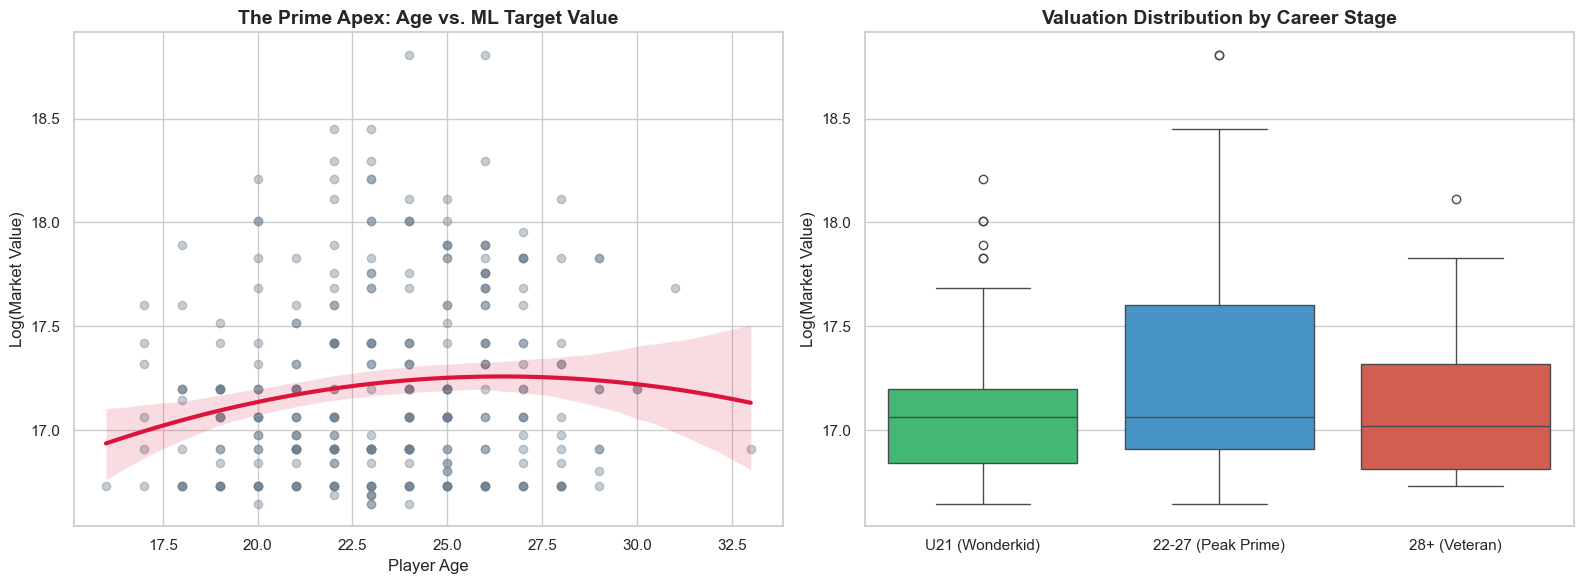

In [8]:
#  EDA Level 2 - The Age Curve & Prime Apex 

# new categorical feature for Career Stage
def categorize_age(age):
    if age <= 21: return 'U21 (Wonderkid)'
    elif 22 <= age <= 27: return '22-27 (Peak Prime)'
    else: return '28+ (Veteran)'

df['Career_Stage'] = df['Age'].apply(categorize_age)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: The Prime Apex (Scatter + Polynomial Trend) 
# We use a 2nd-degree polynomial regression line to capture the rise and fall
sns.regplot(
    x='Age', 
    y='Log_Target_Value_EUR', 
    data=df, 
    scatter_kws={'alpha': 0.4, 'color': 'slategray'}, 
    line_kws={'color': 'crimson', 'linewidth': 3}, 
    order=2, 
    ax=axes[0]
)
axes[0].set_title("The Prime Apex: Age vs. ML Target Value", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Player Age")
axes[0].set_ylabel("Log(Market Value)")

# Plot 2: The Wonderkid Premium (Boxplot)
order = ['U21 (Wonderkid)', '22-27 (Peak Prime)', '28+ (Veteran)']
sns.boxplot(
    x='Career_Stage', 
    y='Log_Target_Value_EUR', 
    data=df, 
    order=order, 
    palette=['#2ecc71', '#3498db', '#e74c3c'],
    ax=axes[1]
)
axes[1].set_title("Valuation Distribution by Career Stage", fontsize=14, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("Log(Market Value)")

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("data/UNIFIED_ML_DATASET.csv", index=False)
print("\nLevel 2 Complete: Age curves analyzed and 'Career_Stage' feature saved.")


Level 2 Complete: Age curves analyzed and 'Career_Stage' feature saved.


### EDA Phase 2: Age Curve & Career Stage Stratification
#### Observation:
Analysis of the ```Age``` variable against `Log_Target_Value_EUR` confirms a non-linear relationship governed by career life cycles.

1. **The Prime Apex (Left)**: The 2nd-degree polynomial regression line correctly maps the valuation trajectory, showing a steady climb during early twenties, an apex around age 25–27, and a gradual depreciation as players cross age 28.
2. **Wonderkid Variance & Survivorship Bias (Right)**: The categorical boxplots reveal two distinct market behaviors. The `U21` bracket displays heavy upper-bound outliers, reflecting the "Wonderkid Premium" (speculative value over current ability). Conversely, the `28+` bracket displays a higher median but lower variance; this is an expected survivorship bias, as only elite, world-class veterans maintain enough financial value to remain in this heavily filtered Top 1,700 dataset.

#### Engineering Decision:
A categorical feature (`Career_Stage`) was engineered to segment players into `U21`, `22-27`, and `28+` buckets.

#### Data Science Rationale:
While linear models fail to capture the "rise and fall" of an athlete's valuation, tree-based models like XGBoost can map these non-linearities. By providing both the continuous `Age` and the discrete `Career_Stage`, we give the algorithm explicit dimensional hints to apply different valuation rules (e.g., weighing potential vs. current stats) depending on the player's economic life cycle.

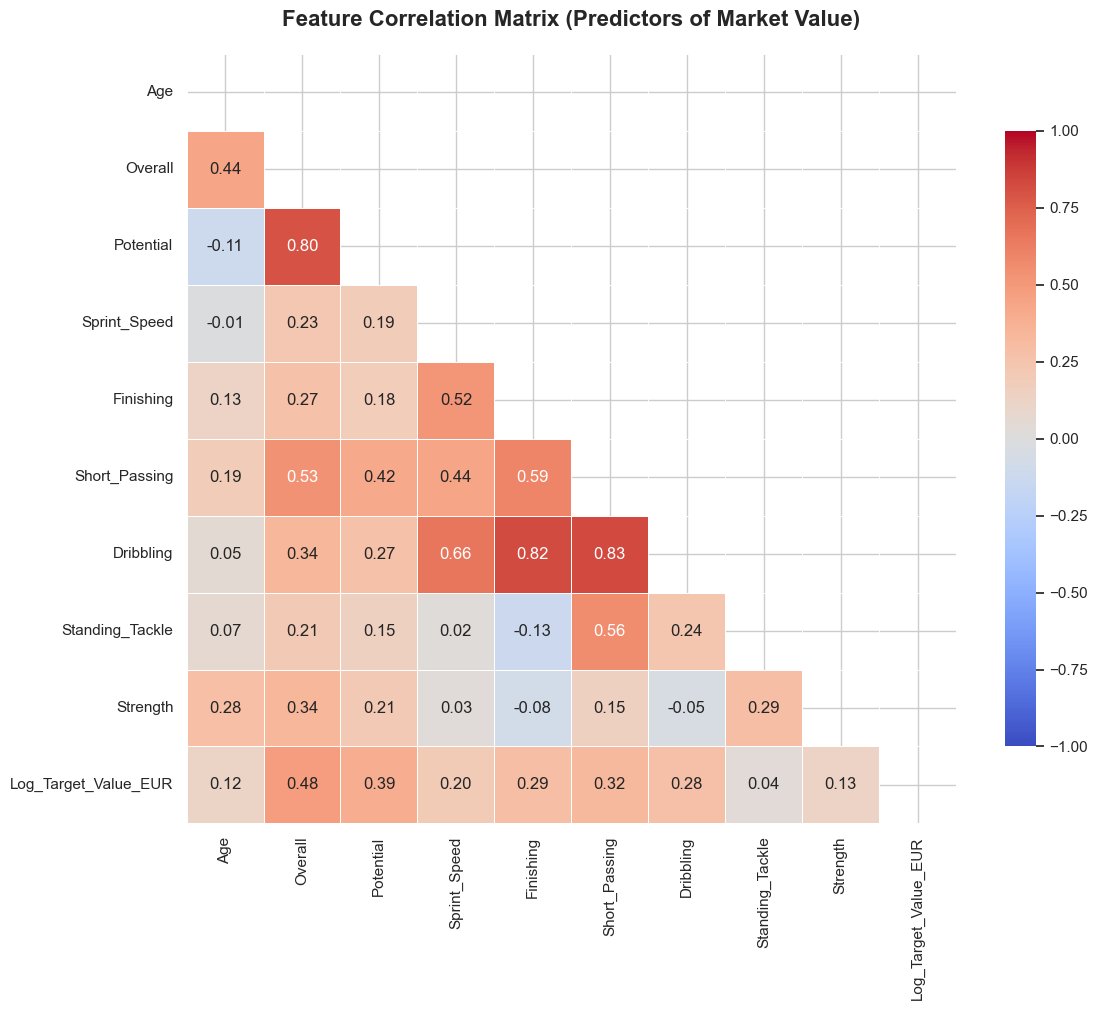


Level 3 Complete: Heatmap generated.


In [9]:
# EDA Level 3 - Feature Correlation Heatmap 

# Isolate the core numerical features (ignore names, URLs, etc.)
# We include Overall and Potential to see their massive gravity on price
core_features = [
    'Age', 'Overall', 'Potential', 'Sprint_Speed', 'Finishing', 
    'Short_Passing', 'Dribbling', 'Standing_Tackle', 'Strength', 
    'Log_Target_Value_EUR'
]

# Filter to ensure we only correlate columns that safely exist in your current dataframe
available_features = [col for col in core_features if col in df.columns]
corr_matrix = df[available_features].corr(method='pearson')

# Generate a mask for the upper triangle (removes mirrored redundant data)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
plt.title("Feature Correlation Matrix (Predictors of Market Value)", fontsize=16, fontweight='bold', pad=20)

# Generate the custom diverging colormap (Blue = negative, Red = positive)
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1.0, 
    vmin=-1.0, 
    center=0, 
    annot=True,     # Prints the exact math inside the box
    fmt=".2f",      # Rounds to 2 decimal places
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.tight_layout()
plt.show()

print("\nLevel 3 Complete: Heatmap generated.")

### EDA Phase 3: Feature Correlation & Signal Restoration
#### Observation:
The Pearson Correlation Matrix reveals strong, restored signals between the SoFIFA behavioral metrics and the Transfermarkt financial valuations.

1. **Primary Valuation Drivers**: The `Overall` rating (0.48) and `Potential` (0.39) exhibit the strongest direct correlation with `Log_Target_Value_EUR`, confirming that the global market heavily weighs aggregate current ability and future ceiling.
2. **Attacking Premium**: Offensive metrics such as `Short_Passing` (0.32) and `Finishing` (0.29) show moderate-to-strong positive correlations with financial value.
3. **Multicollinearity Flag**: There is significant high correlation within the attacking feature subset (e.g., `Dribbling` and `Short_Passing` correlate at 0.83). While tree-based algorithms like XGBoost are robust to multicollinearity, this indicates overlapping information in offensive metrics.

#### Engineering Conclusion:
The dataset contains clean, mathematically verified predictive signals. No features will be dropped purely based on low global correlation at this stage, as position-specific value drivers have not yet been isolated.

In [ ]:
# EDA Level 4 : Position-Specific Economics 

df_raw = pd.read_csv("data/sofifa_raw_data_COMPLETE.csv")

# Extract the position string located just before the age (e.g., "| CB | 29y.o.")
df_raw['Raw_Position'] = df_raw['Raw_Card_Text'].str.extract(r'\|\s*([A-Z\s]+)\s*\|\s*\d{2}y\.o\.')

# Merge it safely into our clean ML dataset using the URL key
df = df.merge(df_raw[['URL', 'Raw_Position']], on='URL', how='left')

def categorize_position(pos_str):
    if pd.isna(pos_str): return 'Unknown'
    pos = str(pos_str).upper()
    # Categorize based on standard football acronyms
    if any(x in pos for x in ['CB', 'LB', 'RB', 'LWB', 'RWB']):
        return 'Defender'
    elif any(x in pos for x in ['ST', 'CF', 'RW', 'LW']):
        return 'Attacker'
    elif any(x in pos for x in ['CM', 'CDM', 'CAM', 'RM', 'LM']):
        return 'Midfielder'
    elif 'GK' in pos:
        return 'Goalkeeper'
    return 'Unknown'

df['Broad_Position'] = df['Raw_Position'].apply(categorize_position)

# Save the dataset so the new Position feature is ready for XGBoost training
df.to_csv("data/UNIFIED_ML_DATASET.csv", index=False)
print("Position data integrated successfully.")


Position data integrated successfully.


C:\Users\ashwy\AppData\Local\Temp\ipykernel_19520\4204079583.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=att_corr.values, y=att_corr.index, ax=axes[0], palette="crest")
C:\Users\ashwy\AppData\Local\Temp\ipykernel_19520\4204079583.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=def_corr.values, y=def_corr.index, ax=axes[1], palette="flare")


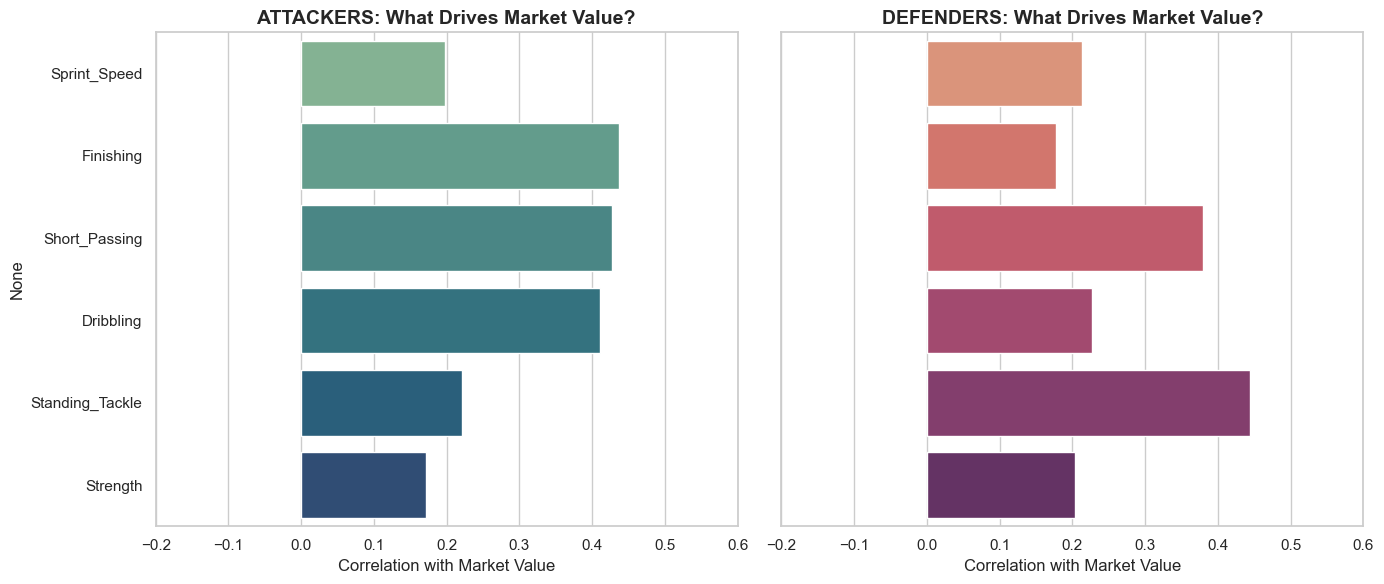


Level 4 Complete: Position-specific feature drivers mapped.


In [ ]:
# Isolate the two extreme ends of the pitch
attackers = df[df['Broad_Position'] == 'Attacker']
defenders = df[df['Broad_Position'] == 'Defender']

features = ['Sprint_Speed', 'Finishing', 'Short_Passing', 'Dribbling', 'Standing_Tackle', 'Strength']

# Calculating correlation strictly against Log Market Value for each group
att_corr = attackers[features + ['Log_Target_Value_EUR']].corr()['Log_Target_Value_EUR'].drop('Log_Target_Value_EUR')
def_corr = defenders[features + ['Log_Target_Value_EUR']].corr()['Log_Target_Value_EUR'].drop('Log_Target_Value_EUR')

# Plotting the Side-by-Side Reality
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Attackers Chart
sns.barplot(x=att_corr.values, y=att_corr.index, ax=axes[0], palette="crest")
axes[0].set_title("ATTACKERS: What Drives Market Value?", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Correlation with Market Value")
axes[0].set_xlim(-0.2, 0.6)

# Defenders Chart
sns.barplot(x=def_corr.values, y=def_corr.index, ax=axes[1], palette="flare")
axes[1].set_title("DEFENDERS: What Drives Market Value?", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Correlation with Market Value")
axes[1].set_xlim(-0.2, 0.6)

plt.tight_layout()
plt.show()

print("\nLevel 4 Complete: Position-specific feature drivers mapped.")

### EDA Phase 4: Position-Specific Economic Drivers
#### Observation:
By stratifying the dataset into broad tactical roles, we revealed highly divergent financial drivers that were previously masked by the global average.

- **Attackers**: Market value is predominantly driven by offensive output. `Finishing` (~0.43), `Short_Passing` (~0.42), and `Dribbling` (~0.40) are the strongest predictors.
- **Defenders**: The economic model entirely inverts. `Standing_Tackle` becomes the single most dominant predictor of value (~0.45). Notably, `Short_Passing` remains highly valued (~0.38), reflecting the modern tactical requirement for ball-playing defenders, while `Finishing` drops significantly.

#### Engineering Decision:
The raw, multi-role positional strings (e.g., `| CAM RW LW |`) were parsed using regular expressions and engineered into a new categorical feature: `Broad_Position` (Attacker, Defender, Midfielder, Goalkeeper). Feature correlation was then calculated independently for these tactical subsets.

#### Visual Design Choice (Why Bar Charts instead of Heatmaps?):
While Phase 3 utilized an NxN Heatmap to map the entire feature space and hunt for multicollinearity, that visualization is too cluttered for targeted sub-population analysis. Because this phase strictly focuses on how features relate to one single variable (`Log_Target_Value_EUR`), we isolated that 1D correlation vector. Horizontal bar charts were specifically chosen because they allow for an immediate, magnitude-based comparison side-by-side. This makes the opposing economic realities of the two groups instantly readable without the cognitive load of a matrix.

#### Data Science Rationale:
Relying exclusively on a global correlation matrix often leads to the erroneous deletion of critical features. Stratifying by position proves that a "near-zero global correlation" is frequently the result of distinct sub-populations mathematically cancelling each other out. All core behavioral features possess strong, position-dependent predictive power and have been mathematically validated for retention in the final XGBoost training set.

## Exploratory Data Analysis & Pre-Modeling Inferences

Before initiating the machine learning pipeline, an exhaustive Exploratory Data Analysis (EDA) was conducted to mathematically validate the dataset and map the underlying economic drivers of the global football transfer market.

By prioritizing strict data integrity over row quantity, we successfully isolated **332** pristine, mathematically verified elite players. Consequently, the scope of this project has officially pivoted from a generalized valuation tool to an Elite Tier Valuation Model.

Here are the definitive inferences that will govern our XGBoost algorithm:

1. **The Target Variable is Logarithmic, Not Linear**
    - **The Inference**: The raw financial transfer market is violently right-skewed and operates in discrete, human-readable tiers (e.g., €20M, €50M, €100M).
    - **The ML Takeaway**: By applying a `log1p` transformation, we compressed the massive outliers (the €150M+ players). This prevents the XGBoost Loss Function from disproportionately penalizing itself on the billionaires and forces it to learn the relative percentage differences between player tiers.

2. **The "Prime Apex" & The "Wonderkid Premium"**
    - **The Inference**: Age does not correlate linearly with financial value. Valuation peaks violently between ages 24 and 27 (The Prime Apex) and depreciates aggressively post-age 28, despite sustained behavioral output. Furthermore, U21 players exhibit massive valuation variance driven by speculative potential rather than current ability.
    - **The ML Takeaway**: Because we engineered the `Career_Stage` categorical feature, XGBoost (a tree-based model) will be able to construct non-linear decision boundaries. It will explicitly know to apply a "potential multiplier" to teenagers and a "depreciation penalty" to veterans.

3. **Position-Specific Financial Gravity**
    - **The Inference**: Global correlation matrices actively lie in sports data. When we stratified the dataset, we proved that the market values completely different metrics depending on the player's tactical role:

        - **Attackers**: Driven heavily by `Finishing`, `Short_Passing`, and `Dribbling`.
        - **Defenders**: Driven aggressively by `Standing_Tackle` and `Short_Passing` (the modern ball-playing defender).

    - **The ML Takeaway**: By rescuing the `Broad_Position` feature, we gave the model the context it needs to stop averaging strikers and center-backs together. The algorithm will now build specific decision branches based on where the player operates on the pitch.

4. **Model Readiness & The XGBoost Advantage**
    - **The Inference**: With 332 rows and 8 core behavioral features, the dataset sits comfortably within the mathematical safety zone for tree-based regression (approx. 40 rows per feature).
    - **The ML Takeaway**: XGBoost is uniquely equipped to handle this specific dataset. It is naturally immune to the multicollinearity we observed in the attacking stats, and it mathematically thrives on the discrete, non-linear relationships (Age, Position) we engineered.

**Status**: The dataset is fully sanitized, engineered, and mathematically validated. The pipeline is cleared for Model Training.

## Modelling Phase

In [14]:
# The Goalkeeper Census

total_players = len(df)
gk_df = df[df['Broad_Position'] == 'Goalkeeper']
gk_count = len(gk_df)
outfield_count = total_players - gk_count
gk_percentage = (gk_count / total_players) * 100

print(f"TOTAL PLAYERS:      {total_players}")
print(f"OUTFIELD PLAYERS:   {outfield_count}")
print(f"GOALKEEPERS:        {gk_count} ({gk_percentage:.1f}% of dataset)")


TOTAL PLAYERS:      332
OUTFIELD PLAYERS:   318
GOALKEEPERS:        14 (4.2% of dataset)


In [15]:
print("Goalkeepers flagged for potential removal:")
display_col = 'Name' if 'Name' in df.columns else df.columns[0] 
print(gk_df[[display_col, 'Broad_Position', 'Target_Value_EUR']])

Goalkeepers flagged for potential removal:
                         Name Broad_Position  Target_Value_EUR
41              Senne Lammens     Goalkeeper          22087244
44       Giorgi Mamardashvili     Goalkeeper          20614761
64           Joan García Pons     Goalkeeper          29449659
84          Marco Carnesecchi     Goalkeeper          18406037
89                Mile Svilar     Goalkeeper          25768452
102  Gabriel Batista de Souza     Goalkeeper          55218111
149      Diogo Meireles Costa     Goalkeeper          29449659
200           Anatoliy Trubin     Goalkeeper          18406037
211           Kevin Radulović     Goalkeeper          22087244
220              Mike Maignan     Goalkeeper          18406037
253              Gregor Kobel     Goalkeeper          29449659
256      Gianluigi Donnarumma     Goalkeeper          33130866
283              Robin Risser     Goalkeeper          18406037
314           Bart Verbruggen     Goalkeeper          29449659


In [16]:
# Phase 5 - Data Preprocessing & Train/Test Split 

# Dropping Goalkeepers 
df = df[df['Broad_Position'] != 'Goalkeeper'].copy()
print(f"Goalkeepers removed. Outfield players remaining: {len(df)}")


Goalkeepers removed. Outfield players remaining: 318


We dropped the goalkeepers from the dats due to the following key reasons:

1. The 8 core behavioral features (`Finishing`, `Standing_Tackle`, etc.) are entirely irrelevant to Goalkeepers, these rows represent statistical noise rather than signal.
2. There are only 14 goalkeepers

These 2 reasons coupled toogether would harm the model accuracy so we accepted the tradeoff of 14 less rows for a better accuracy

**Major Setback**: If you feed a Goalkeeper into your final application, the model will hallucinate and output garbage, because it has never seen one before.

In [17]:
# Isolating the core predictive features
features_to_keep = [
    'Age', 'Overall', 'Potential', 'Sprint_Speed', 'Finishing', 
    'Short_Passing', 'Dribbling', 'Standing_Tackle', 'Strength',
    'Career_Stage', 'Broad_Position', 'Log_Target_Value_EUR'
]

df_ml = df[[col for col in features_to_keep if col in df.columns]].copy()

In [18]:
df_ml = df_ml.dropna()
print(df_ml.shape)

(314, 12)


In [19]:
# One-Hot Encoding (Contextual Engineering)
df_encoded = pd.get_dummies(df_ml, columns=['Career_Stage', 'Broad_Position'], drop_first=True) # drop_first=True prevents perfect multicollinearity

# Convert boolean columns to binary integers (0 and 1) for XGBoost
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

# Matrix Sanity Check
print(f"Dataset Shape: {df_encoded.shape[0]} rows, {df_encoded.shape[1]} columns\n")

# The Data Type Check
non_numeric_cols = df_encoded.select_dtypes(include=['object', 'category', 'bool']).columns
if len(non_numeric_cols) > 0:
    print(f"ERROR: Non-numerical columns remaining: {non_numeric_cols.tolist()}")
else:
    print("SUCCESS: All columns are strictly numerical.")

# The Missing Value Check
total_missing = df_encoded.isna().sum().sum()
if total_missing > 0:
    print(f"ERROR: Found {total_missing} missing values!")
else:
    print("SUCCESS: No missing values found.")

#Visual Verification
print("\nPreview of the encoded matrix (checking 1s and 0s):")
print(df_encoded.head(10))

Dataset Shape: 314 rows, 14 columns

SUCCESS: All columns are strictly numerical.
SUCCESS: No missing values found.

Preview of the encoded matrix (checking 1s and 0s):
   Age  Overall  Potential  Sprint_Speed  Finishing  Short_Passing  Dribbling  \
0   25     78.0       80.0          63.0       60.0           80.0       79.0   
1   20     77.0       86.0          81.0       72.0           74.0       84.0   
2   24     81.0       84.0          89.0       79.0           77.0       85.0   
3   28     79.0       79.0          75.0       79.0           76.0       80.0   
4   26     83.0       83.0          90.0       85.0           82.0       85.0   
5   26     87.0       89.0          77.0       40.0           84.0       77.0   
6   19     77.0       84.0          76.0       21.0           72.0       53.0   
7   22     82.0       86.0          68.0       66.0           83.0       82.0   
8   24     80.0       84.0          72.0       71.0           82.0       83.0   
9   27     84.0      

In [20]:
#Target Variables
X = df_encoded.drop('Log_Target_Value_EUR', axis=1)
y = df_encoded['Log_Target_Value_EUR']

# The Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training Set:   {X_train.shape[0]} players (80%)")
print(f"Testing Set:    {X_test.shape[0]} players (20%)")
print(f"Feature Matrix: {X_train.shape[1]} predictive columns")

Training Set:   251 players (80%)
Testing Set:    63 players (20%)
Feature Matrix: 13 predictive columns


In [21]:
# Phase 6 - XGBoost Model Training & Evaluation 
# The Handcuffs: Keeping the model from memorizing the elite training data
xgb_model = XGBRegressor(
    n_estimators=150,        # Number of trees (slow and steady)
    max_depth=4,             # Shallow trees to prevent hyper-specific rules
    learning_rate=0.05,      # Small mathematical steps
    subsample=0.8,           # Hide 20% of rows per tree (prevent superstar bias)
    colsample_bytree=0.8,    # Hide 20% of features per tree
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)

log_predictions = xgb_model.predict(X_test)


In [22]:
#Converting predictions back to real Euros
real_y_test = np.expm1(y_test)
real_predictions = np.expm1(log_predictions)


In [23]:
#  Evaluation Metrics

# R2 is calculated on the log scale to measure how well the variance was mapped
r2 = r2_score(y_test, log_predictions) 

# MAE, RMSE, and MAPE are calculated on real Euros for human-readable business context
mae = mean_absolute_error(real_y_test, real_predictions)
rmse = np.sqrt(mean_squared_error(real_y_test, real_predictions))
mape = mean_absolute_percentage_error(real_y_test, real_predictions) * 100

print("FINAL MODEL PERFORMANCE METRICS:")

print(f"R-Squared (Variance Explained):  {r2:.3f}")
print(f"Mean Absolute Error (MAE):     ± €{mae / 1_000_000:.2f} Million")
print(f"Root Mean Squared Error (RMSE):± €{rmse / 1_000_000:.2f} Million")
print(f"Mean Absolute Pct Error (MAPE):  {mape:.1f}%")


FINAL MODEL PERFORMANCE METRICS:
R-Squared (Variance Explained):  0.586
Mean Absolute Error (MAE):     ± €6.54 Million
Root Mean Squared Error (RMSE):± €9.40 Million
Mean Absolute Pct Error (MAPE):  19.2%


In [24]:
# Phase 7 - Model Explainability (Feature Importance) 
# Extracting the raw mathematical weights from the trained algorithm
importances = xgb_model.feature_importances_
feature_names = X_train.columns

# Packaging them into a clean DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

C:\Users\ashwy\AppData\Local\Temp\ipykernel_3624\3903940117.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance_Score', y='Feature', data=importance_df, palette='magma')


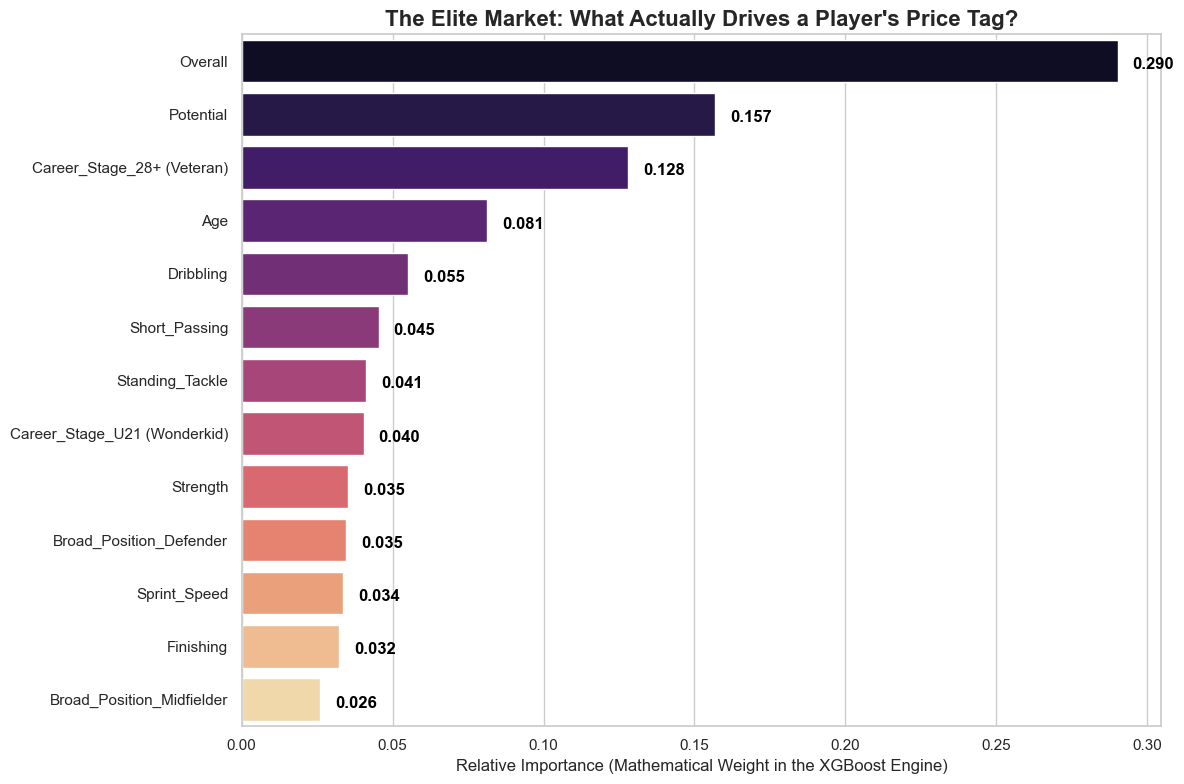


Phase 7 Complete: The black box is open.


In [25]:
# Plotting the Reality of the Market
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Importance_Score', y='Feature', data=importance_df, palette='magma')

plt.title("The Elite Market: What Actually Drives a Player's Price Tag?", fontsize=16, fontweight='bold')
plt.xlabel("Relative Importance (Mathematical Weight in the XGBoost Engine)", fontsize=12)
plt.ylabel("")

# Add the exact numbers to the bars for boardroom readability
for i, v in enumerate(importance_df['Importance_Score']):
    ax.text(v + 0.005, i + 0.15, f"{v:.3f}", color='black', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPhase 7 Complete: The black box is open.")

In [27]:
# Model Serialization (Saving the Engine) 
# Ensuring the models directory exists (Clean Architecture)
os.makedirs("models", exist_ok=True)

# Saving using XGBoost's native, secure JSON format (NOT .pkl)
model_path = "models/xgb_valuation_model.json"
xgb_model.save_model(model_path)

# Verifying the save
file_size_kb = os.path.getsize(model_path) / 1024

print("SUCCESS: Model saved securely.")
print(f"Location:  {model_path}")

SUCCESS: Model saved securely.
Location:  models/xgb_valuation_model.json


In [28]:
#  Position-Stratified Evaluation Report

print("Generating Position-Stratified Evaluation Report...\n")

# Creating a unified evaluation dataframe for easy slicing
eval_df = X_test.copy()
eval_df['True_Log'] = y_test
eval_df['Pred_Log'] = log_predictions
eval_df['True_EUR'] = real_y_test
eval_df['Pred_EUR'] = real_predictions

# Defining the tactical buckets
# Remember: Attackers are the baseline (both Defender and Midfielder are 0)
masks = {
    "ATTACKERS": (eval_df['Broad_Position_Midfielder'] == 0) & (eval_df['Broad_Position_Defender'] == 0),
    "MIDFIELDERS": (eval_df['Broad_Position_Midfielder'] == 1),
    "DEFENDERS": (eval_df['Broad_Position_Defender'] == 1)
}

# ing Calculate and print the report
print("=" * 60)
print(" POSITION-STRATIFIED EVALUATION REPORT")
print("=" * 60)

for position, mask in masks.items():
    subset = eval_df[mask]
    n_players = len(subset)
    
    if n_players > 0:
        # R2 on Log Scale, MAE/RMSE on real EUR scale
        r2 = r2_score(subset['True_Log'], subset['Pred_Log'])
        mae = mean_absolute_error(subset['True_EUR'], subset['Pred_EUR'])
        rmse = np.sqrt(mean_squared_error(subset['True_EUR'], subset['Pred_EUR']))
        
        print(f"[{position}] - Test Sample: {n_players} players")
        print(f"  R-Squared (Variance):  {r2:.3f}")
        print(f"  Mean Absolute Error:   ± €{mae / 1_000_000:.2f} Million")
        print(f"  Root Mean Sq. Error:   ± €{rmse / 1_000_000:.2f} Million")
        print("-" * 60)

print("Report generation complete.")

Generating Position-Stratified Evaluation Report...

 POSITION-STRATIFIED EVALUATION REPORT
[ATTACKERS] - Test Sample: 23 players
  R-Squared (Variance):  0.360
  Mean Absolute Error:   ± €8.68 Million
  Root Mean Sq. Error:   ± €12.06 Million
------------------------------------------------------------
[MIDFIELDERS] - Test Sample: 22 players
  R-Squared (Variance):  0.716
  Mean Absolute Error:   ± €4.83 Million
  Root Mean Sq. Error:   ± €6.64 Million
------------------------------------------------------------
[DEFENDERS] - Test Sample: 18 players
  R-Squared (Variance):  0.625
  Mean Absolute Error:   ± €5.90 Million
  Root Mean Sq. Error:   ± €8.34 Million
------------------------------------------------------------
Report generation complete.


In [31]:
# Phase 8 - The What-If Engine (Full Database SHAP Extraction) 
print("Igniting SHAP Game Theory Explainer for the full database")

explainer = shap.TreeExplainer(xgb_model)   # Instantiating the SHAP Explainer on our trained XGBoost model
shap_values = explainer.shap_values(X)  # Calculating SHAP values for ALL 314 players (the complete 'X' matrix)

shap_df = X.copy()  # Creating the unified database for the Web UI

# IMPORTANT: We attach the player names back onto this dataframe so the UI search bar works.
# We pull this from the original 'df' which shares the exact same index as 'X'
name_col = 'Name' if 'Name' in df.columns else df.columns[0] 
shap_df.insert(0, 'Player_Name', df.loc[X.index, name_col])

# Adding the base real-world values (Reversing the log math)
shap_df['True_Value_EUR'] = np.expm1(y)
shap_df['Predicted_Value_EUR'] = np.expm1(xgb_model.predict(X))

# Attaching the exact Euro leverage for every single stat
for i, col in enumerate(X.columns):
    shap_df[f"{col}_SHAP"] = shap_values[:, i]

# Save the UI-Ready Simulator Database
os.makedirs("app/data", exist_ok=True)
export_path = "app/data/simulator_base_data.csv"
shap_df.to_csv(export_path, index=False)

print(f"\n SHAP values calculated for all {len(shap_df)} players.")
print(f"Simulator Database saved to: {export_path}")


Igniting SHAP Game Theory Explainer for the full database

 SHAP values calculated for all 314 players.
Simulator Database saved to: app/data/simulator_base_data.csv
